# Customer Churn Analysis & Retention Strategy

##  Problem Statement
Customer churn is a major challenge for subscription-based businesses, directly impacting revenue and long-term growth. Identifying why customers leave is critical for improving retention.

##  Objective
To identify key churn drivers, uncover high-risk customer segments, and quantify the business impact of churn.

##  Approach
- Identify where churn is coming from
- Understand behavioral drivers
- Evaluate financial impact
- Recommend actionable strategies

##  Outcome
A data-driven churn playbook to reduce churn and protect revenue.

In [80]:
# Data Cleaning and library import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Target
df["Churn_Binary"] = df["Churn"].map({"Yes":1, "No":0})

# Fix TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# Tenure groups
df["tenure_group"] = pd.cut(df["tenure"], bins=[0,12,24,48,72])

# Number of services
services = ['PhoneService','OnlineSecurity','OnlineBackup','DeviceProtection',
            'TechSupport','StreamingTV','StreamingMovies']
df['num_services'] = df[services].apply(lambda x: (x=="Yes").sum(), axis=1)

/tmp/ipykernel_250/3101844598.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


In [79]:
#2. Data Overview
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   object  
 1   gender            7043 non-null   object  
 2   SeniorCitizen     7043 non-null   int64   
 3   Partner           7043 non-null   object  
 4   Dependents        7043 non-null   object  
 5   tenure            7043 non-null   int64   
 6   PhoneService      7043 non-null   object  
 7   MultipleLines     7043 non-null   object  
 8   InternetService   7043 non-null   object  
 9   OnlineSecurity    7043 non-null   object  
 10  OnlineBackup      7043 non-null   object  
 11  DeviceProtection  7043 non-null   object  
 12  TechSupport       7043 non-null   object  
 13  StreamingTV       7043 non-null   object  
 14  StreamingMovies   7043 non-null   object  
 15  Contract          7043 non-null   object  
 16  PaperlessBilling  7043 n

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn_Binary,num_services
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928,0.265370,2.941076
std,0.368612,24.559481,30.090047,2265.270398,0.441561,1.843899
min,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,402.225000,0.000000,1.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000,3.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000,4.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000,7.000000


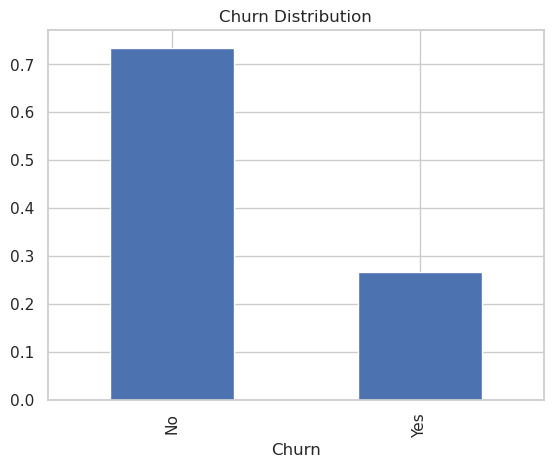

In [42]:
# 3. Where is the churn coming from? [Understanding the Problem]
#churn distribution
df['Churn'].value_counts(normalize=True).plot(kind='bar')
plt.title("Churn Distribution")
plt.show()

###  Insight
A significant proportion of customers have churned, indicating a serious retention issue that needs immediate attention.

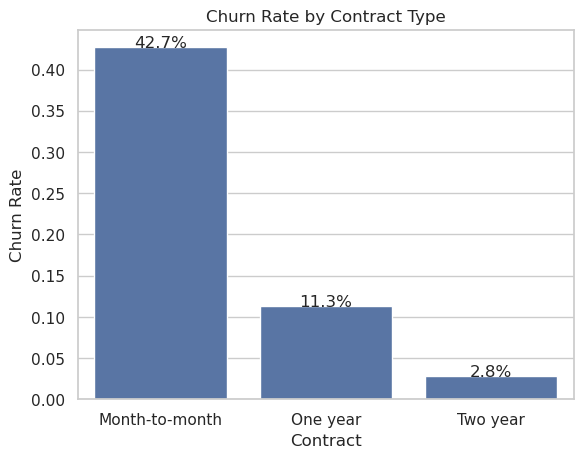

In [58]:
#contract type of people who have churned
data = df.groupby("Contract")["Churn_Binary"].mean().reset_index()

sns.barplot(x="Contract", y="Churn_Binary", data=data)

for i, row in data.iterrows():
    plt.text(i, row["Churn_Binary"], f"{row['Churn_Binary']*100:.1f}%", ha='center')

plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.show()

### Insight
Customers on month-to-month contracts show significantly higher churn compared to long-term contracts. This indicates low commitment levels and highlights an opportunity to improve retention by encouraging longer-term plans.

/tmp/ipykernel_250/1802262510.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data = df.groupby("tenure_group")["Churn_Binary"].mean().reset_index()


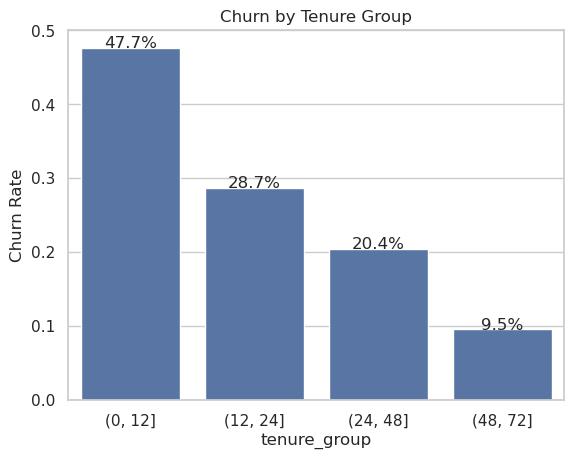

In [59]:
#Tenure of those who churned
data = df.groupby("tenure_group")["Churn_Binary"].mean().reset_index()

sns.barplot(x="tenure_group", y="Churn_Binary", data=data)

for i, row in data.iterrows():
    plt.text(i, row["Churn_Binary"], f"{row['Churn_Binary']*100:.1f}%", ha='center')

plt.title("Churn by Tenure Group")
plt.ylabel("Churn Rate")
plt.show()

###  Insight
Churn is highest among customers in their early tenure (0–1 year), indicating onboarding and early engagement issues. Customers who stay longer are significantly more stable.

In [71]:
#Early churn Risk
early_churn = df[df['tenure'] <= 6]['Churn'].value_counts(normalize=True)
print("Churn rate for first 6 months:")
print(early_churn)

Churn rate for first 6 months:
Churn
Yes    0.529372
No     0.470628
Name: proportion, dtype: float64


### Insight
Churn is highest in the early tenure period, indicating that customers are most likely to leave shortly after joining. This highlights onboarding and early engagement as critical retention levers.

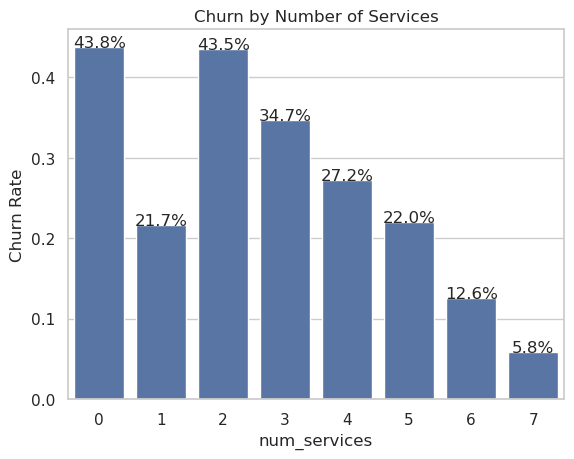

In [60]:
#Number of services
data = df.groupby("num_services")["Churn_Binary"].mean().reset_index()

sns.barplot(x="num_services", y="Churn_Binary", data=data)

for i, row in data.iterrows():
    plt.text(i, row["Churn_Binary"], f"{row['Churn_Binary']*100:.1f}%", ha='center')

plt.title("Churn by Number of Services")
plt.ylabel("Churn Rate")
plt.show()

###  Insight
Customers using fewer services exhibit higher churn, suggesting lower engagement. Increased service adoption appears to improve customer stickiness.

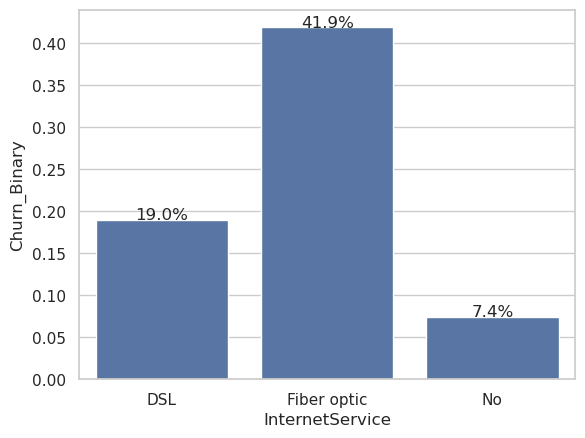

In [63]:
#Internet Service
data = df.groupby("InternetService")["Churn_Binary"].mean().reset_index()

sns.barplot(x="InternetService", y="Churn_Binary", data=data)
for i, row in data.iterrows():
    plt.text(i, row["Churn_Binary"], f"{row['Churn_Binary']*100:.1f}%", ha='center')

plt.show()

### Insight
Churn varies across internet service types, suggesting differences in satisfaction or pricing perception.

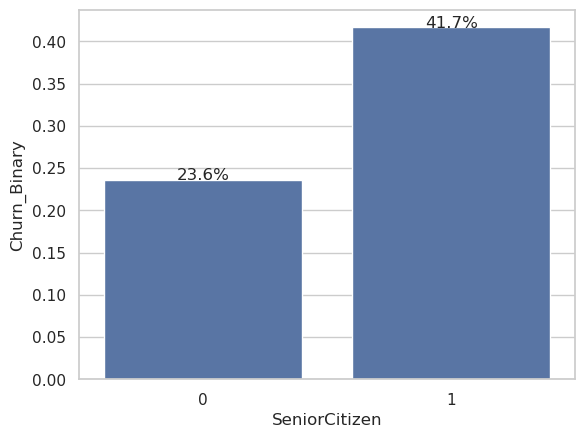

In [64]:
#Senior Citizen
data = df.groupby("SeniorCitizen")["Churn_Binary"].mean().reset_index()

sns.barplot(x="SeniorCitizen", y="Churn_Binary", data=data)
for i, row in data.iterrows():
    plt.text(i, row["Churn_Binary"], f"{row['Churn_Binary']*100:.1f}%", ha='center')

plt.show()

### Insight
Senior citizens show distinct churn behavior, indicating different needs and expectations.

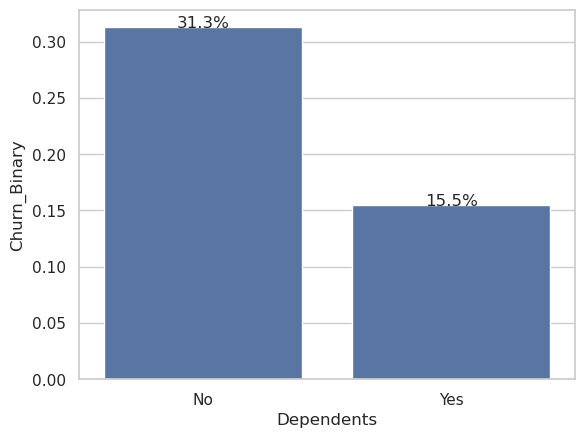

In [65]:
#Dependents
data = df.groupby("Dependents")["Churn_Binary"].mean().reset_index()

sns.barplot(x="Dependents", y="Churn_Binary", data=data)
for i, row in data.iterrows():
    plt.text(i, row["Churn_Binary"], f"{row['Churn_Binary']*100:.1f}%", ha='center')

plt.show()

### Insight
Customers without dependents churn more, suggesting lower long-term commitment.

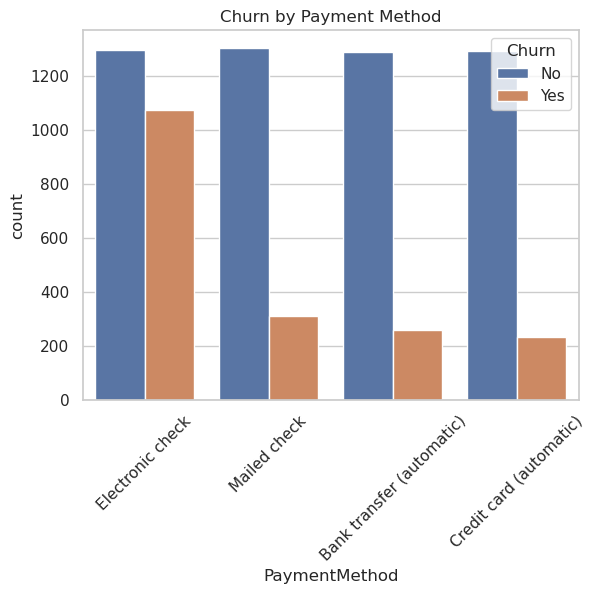

In [46]:
# 4. Why are customers churning? 
#Payment Method
sns.countplot(data=df, x='PaymentMethod', hue='Churn')
plt.xticks(rotation=45)
plt.title("Churn by Payment Method")
plt.show()

### Insight
Customers using manual payment methods show higher churn, indicating potential friction in payment processes. Promoting automatic payment options could improve retention.

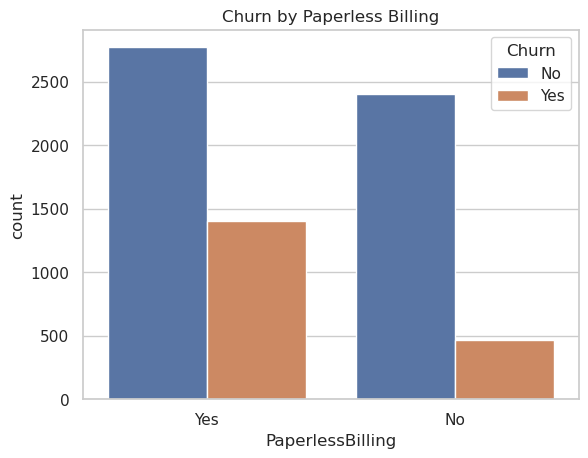

In [69]:
#Paperless Billing 
sns.countplot(data=df, x='PaperlessBilling', hue='Churn')
plt.title("Churn by Paperless Billing")
plt.show()

### Insight
Customers using paperless billing show slightly different churn behavior, often overlapping with digital payment preferences.

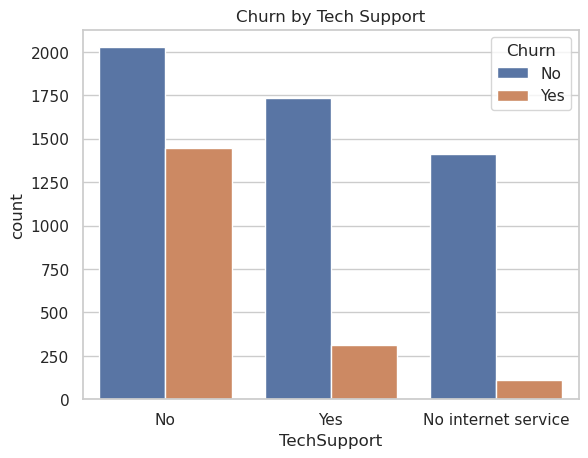

In [47]:
#Tech Support
sns.countplot(data=df, x='TechSupport', hue='Churn')
plt.title("Churn by Tech Support")
plt.show()

### Insight
Customers without tech support exhibit significantly higher churn, highlighting the importance of customer support as a key retention driver.

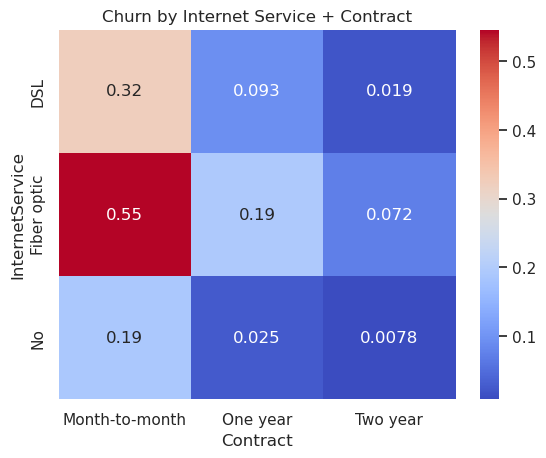

In [72]:
#internet service+ contract
pivot = df.pivot_table(values="Churn_Binary",
                       index="InternetService",
                       columns="Contract",
                       aggfunc="mean")

sns.heatmap(pivot, annot=True, cmap="coolwarm")

plt.title("Churn by Internet Service + Contract")
plt.show()

### Insight
Customers using fiber optic services on month-to-month contracts show the highest churn rates, indicating a high-risk segment driven by both pricing sensitivity and lack of long-term commitment.

/tmp/ipykernel_250/805545230.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(values="Churn_Binary", index="tenure_group",


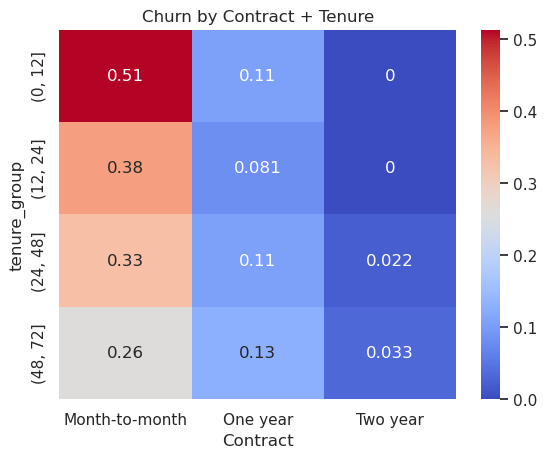

In [66]:
#Contract + Tenure
pivot = df.pivot_table(values="Churn_Binary", index="tenure_group",
                       columns="Contract", aggfunc="mean")

sns.heatmap(pivot, annot=True, cmap="coolwarm")
plt.title("Churn by Contract + Tenure")
plt.show()

###  Insight
Customers on monthly contracts with low tenure are the most likely to churn, indicating a high-risk segment driven by low commitment and poor early experience.

In [53]:
# 5. BUSINESS IMPACT
#churn rate
churn_rate = (df['Churn'] == 'Yes').mean() * 100
print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 26.54%


### Insight
A significant portion of customers are leaving, posing a major retention challenge.

In [68]:
#Revenue at Risk
churn_rev = df[df["Churn_Binary"]==1]["MonthlyCharges"].sum()
total_rev = df["MonthlyCharges"].sum()

print(f"Revenue at Risk: {(churn_rev/total_rev)*100:.2f}%")

Revenue at Risk: 30.50%


###  Insight
A substantial amount of revenue is being lost due to customer churn, emphasizing the financial impact of retention issues.

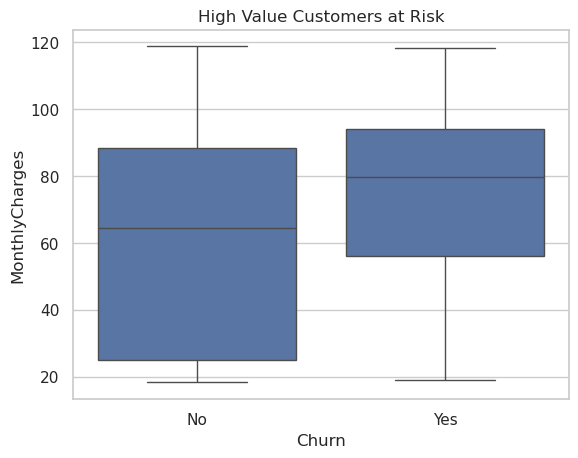

In [50]:
#High Value Customers at risk
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title("High Value Customers at Risk")
plt.show()

### Insight
High-paying customers are also churning, indicating that the issue is not limited to low-value users and requires urgent attention.

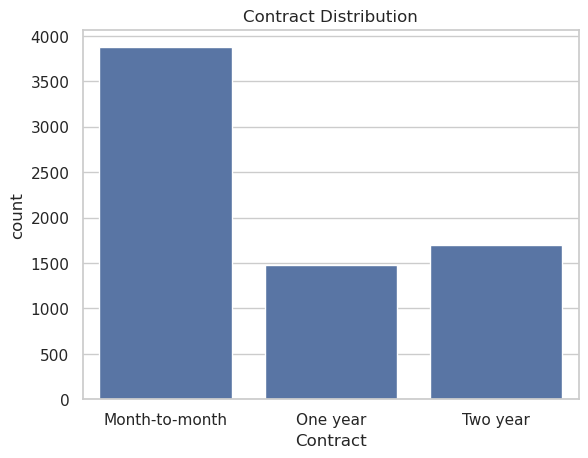

In [73]:
#Contract Distribution
sns.countplot(data=df, x='Contract')
plt.title("Contract Distribution")
plt.show()

### Insight
A large proportion of customers are on month-to-month contracts, exposing the business to higher churn risk due to lack of long-term commitment.

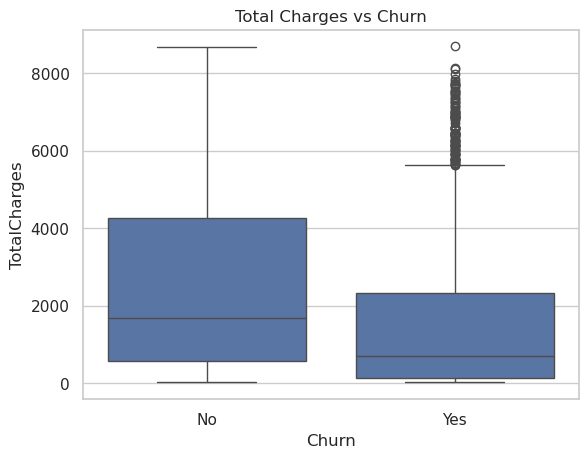

In [70]:
#Total Charges vs Churn 
sns.boxplot(data=df, x='Churn', y='TotalCharges')
plt.title("Total Charges vs Churn")
plt.show() 


### Insight
Customers who churn tend to have lower total charges, suggesting that long-term customers are more likely to stay, while newer customers contribute less overall revenue before leaving.

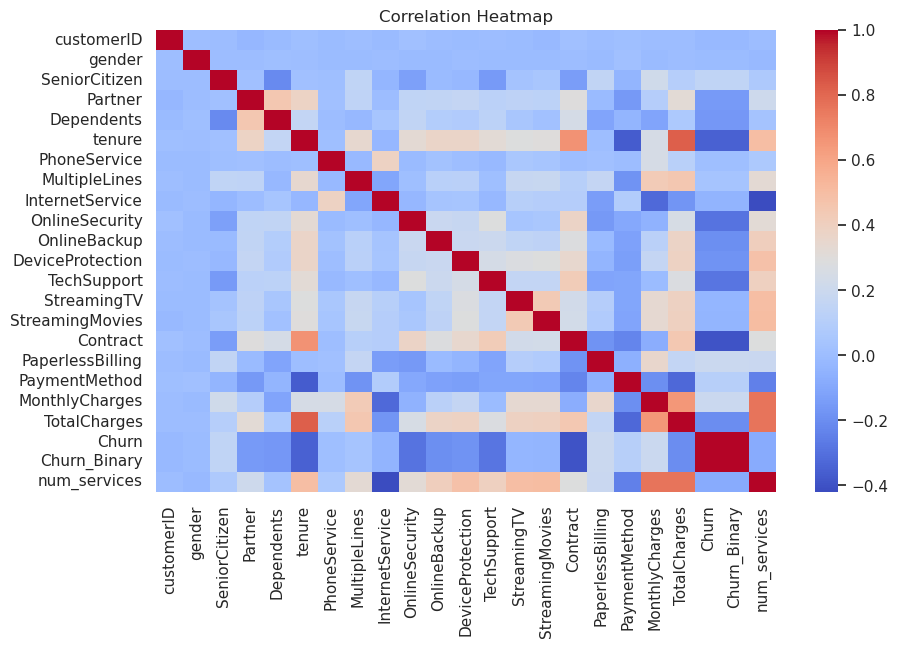

In [83]:
#6. Supporting Analysis
#Correlation Heatmap
df_encoded = df.copy()
df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df_encoded.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Insight
Correlation analysis supports earlier findings, highlighting strong relationships between churn and factors such as tenure and charges.

# 7. Actionable Churn Playbook

Based on the analysis, churn can be reduced by targeting specific high-risk customer segments with tailored actions.


### Early Churn Risk (Onboarding Problem)
Customers with low tenure are most likely to churn.
→ Action: Improve onboarding, send engagement emails, offer early incentives.

### Contract Conversion Opportunity
A large portion of customers are on month-to-month contracts, making them highly prone to churn.
→ Action: Offer discounts or benefits to shift them to long-term contracts.

###  Payment Friction
Customers using manual payment methods show higher churn.
→ Action: Encourage auto-pay through cashback or discounts.

###  Low Engagement Users
Customers using fewer services are more likely to churn.
→ Action: Recommend bundled services to increase engagement.

###  High Value Customers at Risk
High-paying customers contribute significantly to revenue but are also at risk.
→ Action: Provide VIP support, personalized offers, and priority service.

###  Service Experience Issues
Customers without tech support or with certain internet services show higher churn.
→ Action: Bundle tech support or improve service quality.

In [76]:
# Create High Value column 
df['HighValue'] = df['MonthlyCharges'] > df['MonthlyCharges'].median()

# Initialize
df['Action'] = "Monitor"

#  High Value → highest priority
df.loc[df['HighValue'] == True, 'Action'] = "VIP Support"

#  Early churn risk
df.loc[(df['tenure'] < 6) & (df['Action'] == "Monitor"),
       'Action'] = "Onboarding Engagement"

#  Contract conversion
df.loc[(df['Contract'] == 'Month-to-month') & (df['Action'] == "Monitor"),
       'Action'] = "Offer Long-term Discount"

# Payment friction
df.loc[(df['PaymentMethod'].str.contains("check")) & (df['Action'] == "Monitor"),
       'Action'] = "Promote Auto-Pay"

#  Low engagement
df.loc[(df['num_services'] <= 2) & (df['Action'] == "Monitor"),
       'Action'] = "Bundle Services"

#  No tech support
df.loc[(df['TechSupport'] == 'No') & (df['Action'] == "Monitor"),
       'Action'] = "Offer Tech Support"

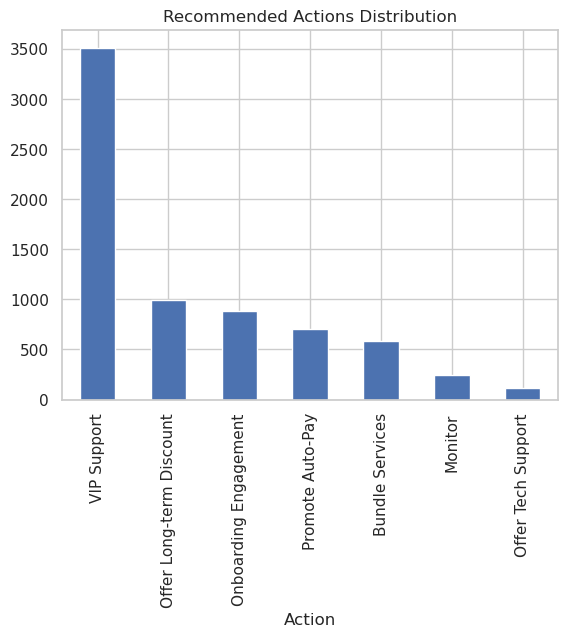

In [77]:
df['Action'].value_counts().plot(kind='bar')
plt.title("Recommended Actions Distribution")
plt.show()

### Insight
Churn drivers can be translated into targeted business actions. By segmenting customers based on risk factors, the company can apply personalized strategies such as onboarding support, contract incentives, and service improvements to effectively reduce churn.

In [78]:
df.groupby("Action")["Churn_Binary"].mean().sort_values(ascending=False)

Action
Onboarding Engagement       0.433898
VIP Support                 0.351920
Offer Long-term Discount    0.195980
Offer Tech Support          0.062500
Monitor                     0.045643
Promote Auto-Pay            0.033898
Bundle Services             0.018739
Name: Churn_Binary, dtype: float64

### Insight
The churn rate across action segments confirms that high-risk groups such as onboarding users and month-to-month customers have the highest churn, validating the effectiveness of the targeted action strategy.